In [1]:
# Cell 1: Import libraries
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [6]:
# Cell 2: Load the training data and check structure
speed_train = joblib.load('data/fbank_speed.train.joblib')
tempo_train = joblib.load('data/fbank_tempo.train.joblib')

print("Speed training data keys:", speed_train.keys())
print("Tempo training data keys:", tempo_train.keys())

# Let's see what type of object this is
print("\nType of speed_train:", type(speed_train))
print("Type of tempo_train:", type(tempo_train))

# If it's a Bunch object, try this:
if hasattr(speed_train, 'data'):
    print("\nIt's a Bunch object!")
    print("Speed data shape:", speed_train.data.shape)
else:
    print("\nIt's a regular dictionary")
    # Print all keys to see what's available
    for key in speed_train.keys():
        print(f"Key: '{key}', Type: {type(speed_train[key])}")

Speed training data keys: dict_keys(['features', 'target', 'filenames'])
Tempo training data keys: dict_keys(['features', 'target', 'filenames'])

Type of speed_train: <class 'dict'>
Type of tempo_train: <class 'dict'>

It's a regular dictionary
Key: 'features', Type: <class 'numpy.ndarray'>
Key: 'target', Type: <class 'numpy.ndarray'>
Key: 'filenames', Type: <class 'list'>


In [13]:
# Cell 3: Check data shapes and sizes
print("\n=== SPEED DATA ===")
print(f"Training samples: {speed_train['features'].shape}")
print(f"Number of features per sample: {speed_train['features'].shape[1]}")
print(f"Labels shape: {speed_train['target'].shape}")
print(f"Number of files: {len(speed_train['filenames'])}")

print("\n=== TEMPO DATA ===")
print(f"Training samples: {tempo_train['features'].shape}")
print(f"Number of features per sample: {tempo_train['features'].shape[1]}")
print(f"Labels shape: {tempo_train['target'].shape}")
print(f"Number of files: {len(tempo_train['filenames'])}")


=== SPEED DATA ===
Training samples: (4155, 6464)
Number of features per sample: 6464
Labels shape: (4155,)
Number of files: 4155

=== TEMPO DATA ===
Training samples: (4155, 6464)
Number of features per sample: 6464
Labels shape: (4155,)
Number of files: 4155



=== CLASS DISTRIBUTIONS ===
Speed classes: {np.float64(2.0): 831, np.float64(0.0): 831, np.float64(4.0): 831, np.float64(1.0): 831, np.float64(3.0): 831}
Tempo classes: {np.float64(1.0): 831, np.float64(3.0): 831, np.float64(2.0): 831, np.float64(4.0): 831, np.float64(0.0): 831}


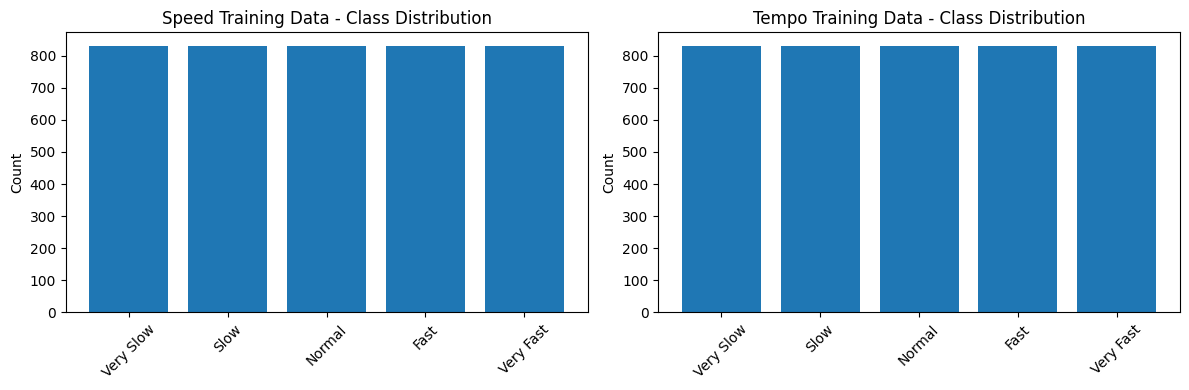

In [14]:
# Cell 4: Check class distributions
print("\n=== CLASS DISTRIBUTIONS ===")
speed_class_counts = Counter(speed_train['target'])
tempo_class_counts = Counter(tempo_train['target'])

class_names = ['Very Slow', 'Slow', 'Normal', 'Fast', 'Very Fast']

print("Speed classes:", dict(speed_class_counts))
print("Tempo classes:", dict(tempo_class_counts))

# Visualize class distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_names, [speed_class_counts[i] for i in range(5)])
axes[0].set_title('Speed Training Data - Class Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(class_names, [tempo_class_counts[i] for i in range(5)])
axes[1].set_title('Tempo Training Data - Class Distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

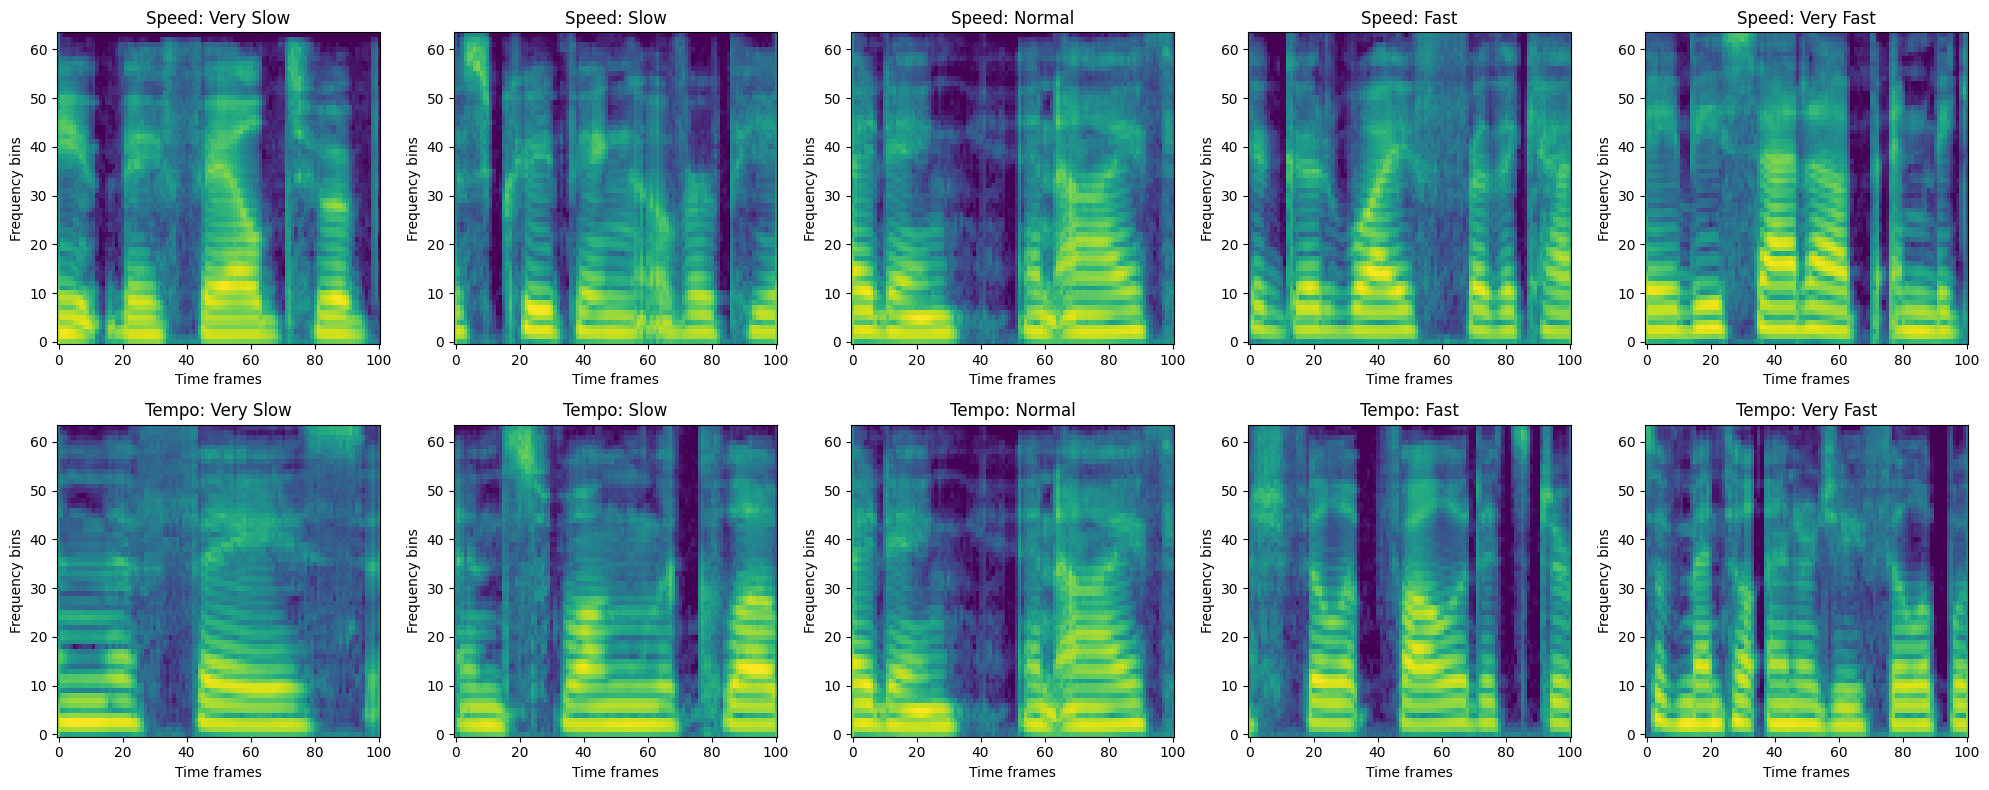

In [15]:
# Cell 5: Visualize filterbank features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

# Speed examples - one from each class
for i in range(5):
    # Find first example of class i
    idx = np.where(speed_train['target'] == i)[0][0]
    features = speed_train['features'][idx].reshape(64, 101)  # CHANGED: 'data' -> 'features'
    
    axes[0, i].imshow(features, aspect='auto', origin='lower', cmap='viridis')
    axes[0, i].set_title(f'Speed: {class_names[i]}')
    axes[0, i].set_xlabel('Time frames')
    axes[0, i].set_ylabel('Frequency bins')

# Tempo examples - one from each class
for i in range(5):
    # Find first example of class i
    idx = np.where(tempo_train['target'] == i)[0][0]
    features = tempo_train['features'][idx].reshape(64, 101)  # CHANGED: 'data' -> 'features'
    
    axes[1, i].imshow(features, aspect='auto', origin='lower', cmap='viridis')
    axes[1, i].set_title(f'Tempo: {class_names[i]}')
    axes[1, i].set_xlabel('Time frames')
    axes[1, i].set_ylabel('Frequency bins')

plt.tight_layout()
plt.show()

In [16]:
# Cell 6: Analyze feature statistics
print("\n=== FEATURE STATISTICS ===")
print("Speed data - mean:", speed_train['features'].mean())
print("Speed data - std:", speed_train['features'].std())
print("Speed data - min:", speed_train['features'].min())
print("Speed data - max:", speed_train['features'].max())

print("\nTempo data - mean:", tempo_train['features'].mean())
print("Tempo data - std:", tempo_train['features'].std())
print("Tempo data - min:", tempo_train['features'].min())
print("Tempo data - max:", tempo_train['features'].max())


=== FEATURE STATISTICS ===
Speed data - mean: -33.00800610107649
Speed data - std: 18.33631020645043
Speed data - min: -76.64070129394531
Speed data - max: 18.645492553710938

Tempo data - mean: -33.203259137874504
Tempo data - std: 18.38639063516872
Tempo data - min: -77.72264099121094
Tempo data - max: 19.48088836669922


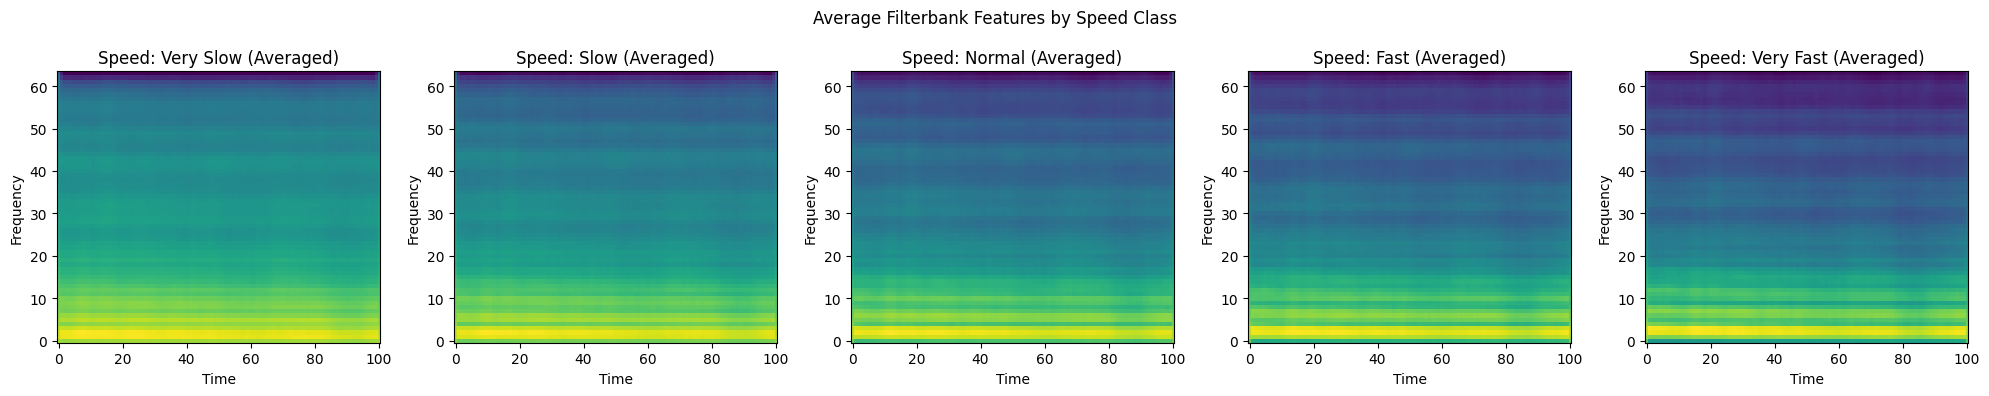

In [17]:
# Cell 7: Compare features across classes
# Average filterbank for each class (speed)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    class_data = speed_train['features'][speed_train['target'] == i]  # CHANGED
    avg_features = class_data.mean(axis=0).reshape(64, 101)
    
    axes[i].imshow(avg_features, aspect='auto', origin='lower', cmap='viridis')
    axes[i].set_title(f'Speed: {class_names[i]} (Averaged)')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Average Filterbank Features by Speed Class')
plt.tight_layout()
plt.show()

In [18]:
# Cell 8: Load test data
speed_test = joblib.load('data/fbank_speed.test1.joblib')
tempo_test = joblib.load('data/fbank_tempo.test1.joblib')

print("\n=== TEST DATA ===")
print(f"Speed test samples: {speed_test['features'].shape}")  # CHANGED
print(f"Tempo test samples: {tempo_test['features'].shape}")  # CHANGED

speed_test_counts = Counter(speed_test['target'])
tempo_test_counts = Counter(tempo_test['target'])
print("Speed test classes:", dict(speed_test_counts))
print("Tempo test classes:", dict(tempo_test_counts))


=== TEST DATA ===
Speed test samples: (500, 6464)
Tempo test samples: (500, 6464)
Speed test classes: {np.float64(2.0): 100, np.float64(1.0): 100, np.float64(3.0): 100, np.float64(4.0): 100, np.float64(0.0): 100}
Tempo test classes: {np.float64(4.0): 100, np.float64(2.0): 100, np.float64(3.0): 100, np.float64(0.0): 100, np.float64(1.0): 100}
